# 메인 전략 노트북: Participation-Stability Top30 Weekly + EGARCH(100/70/30)

이 노트북은 현재 최종 후보 전략을 간결하게 정리한 메인 버전이다.

전략 구조는 아래와 같다.

1. `EGARCH-X`로 시장 전체 변동성 레짐을 판단한다.
2. 레짐 신호는 `5거래일 연속` 확인 후에만 실제 비중에 반영한다.
3. 시장 비중은 `100 / 70 / 30`으로 조절한다.
4. 종목 점수는 `Participation-Stability Score`를 사용한다.
5. 종목 바스켓은 `Top30`, `주간 리밸런싱`, `동일가중`으로 구성한다.
6. 성과는 전체 구간, `2020년 이후`, turnover, 거래비용 10bp 반영 순성과까지 함께 확인한다.

즉 이 노트북은 복잡한 비교 실험을 줄이고, 최종 메인 전략이 실제로 설득력 있는지 빠르게 확인하기 위한 정리본이다.


### 전략 배경

한국 주식시장은 시기별로 고변동 국면과 저변동 국면이 비교적 뚜렷하게 반복되는 특성을 보인다.
특히 고변동 국면에서는 개별 종목 선택보다 시장 전체 변동성의 영향이 포트폴리오 성과를 크게 좌우한다.
한국 시장의 변동성을 GARCH 모형으로 추정한 연구도 다수 존재하므로, 시장 변동성의 시변성을 반영한 접근은 충분한 근거를 가진다.

따라서 본 전략은 GARCH 기반 신호를 통해 고변동 구간에서 총 투자비중을 축소함으로써 시장위험을 선제적으로 관리한다.
한편 종목 선택 단계에서는 FF4 추정을 통해 산출한 market beta를 핵심 factor로 활용한다.
이는 상승장에서는 시장 참여를 충분히 확보하면서, 고변동 구간에서는 시장위험 헤지를 병행하기 위한 구조이다.

구체적으로는 market beta가 `1.1`에 가까운 종목에 더 높은 점수를 부여하고, 동시에 beta 추정오차가 작은 종목을 선호하도록 설계하였다.
이를 `Participation-Stability Score`로 체계화하였다.

이 전략의 논리는 아래 두 축으로 정리할 수 있다.

- `Participation`: market beta가 `1.1`에 가까운 종목 선호
  상승장에서 시장 흐름에 충분히 올라타기 위한 기준
- `Stability`: beta 추정오차가 작은 종목 선호
  추정된 시장 노출이 불안정하지 않고 신뢰 가능한 종목을 선호한다는 의미


### 0. 데이터 불러오기

이 노트북은 무거운 추정을 직접 다시 하지 않는다.
이미 저장된 EGARCH 신호와 FF4 베타를 읽어 메인 전략만 구성한다.


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PRICE_FILE = "1997_2026_코스피코스닥_수정주가_비영업일제외.csv"
FACTOR_FILE = "1997_2026_KOSPI200, SMB, HML, MOM_종가_91CD_일별_비영업일제외.csv"
GARCH_FILE = "garch_roll_params.csv"
BETA_STORE_PICKLE = "ff4_beta_store.pkl.gz"
BETA_STORE_PARQUET = "ff4_beta_store.parquet"

TOP_N = 30
ONE_WAY_COST_BPS = 10
REGIME_CONFIRM_DAYS = 5

required_files = [PRICE_FILE, FACTOR_FILE, GARCH_FILE]
missing_files = [f for f in required_files if not Path(f).exists()]
if missing_files:
    raise FileNotFoundError("다음 파일이 현재 폴더에 없습니다: " + ", ".join(missing_files))

price = pd.read_csv(PRICE_FILE, index_col=0, parse_dates=True).sort_index()
factor = pd.read_csv(FACTOR_FILE, index_col=0, parse_dates=True).sort_index()
garch_roll = pd.read_csv(GARCH_FILE, index_col=0, parse_dates=True).sort_index()

if Path(BETA_STORE_PARQUET).exists():
    beta_store = pd.read_parquet(BETA_STORE_PARQUET)
    beta_store_source = BETA_STORE_PARQUET
elif Path(BETA_STORE_PICKLE).exists():
    beta_store = pd.read_pickle(BETA_STORE_PICKLE, compression="gzip")
    beta_store_source = BETA_STORE_PICKLE
else:
    raise FileNotFoundError("ff4 beta store 파일이 없습니다.")

beta_mkt = beta_store["beta_mkt"].copy().astype(float)
beta_smb = beta_store["beta_smb"].copy().astype(float)
beta_hml = beta_store["beta_hml"].copy().astype(float)
beta_mom = beta_store["beta_mom"].copy().astype(float)
beta_se = beta_store["beta_se"].copy().astype(float)
final_filter = beta_store["final_filter"].copy().fillna(0).astype(bool)

common_stock_cols = price.columns[
    price.columns.isin(beta_mkt.columns)
    & price.columns.isin(beta_smb.columns)
    & price.columns.isin(beta_hml.columns)
    & price.columns.isin(beta_mom.columns)
    & price.columns.isin(beta_se.columns)
    & price.columns.isin(final_filter.columns)
]
if len(common_stock_cols) == 0:
    raise ValueError("price와 beta_store 사이에 공통 종목 컬럼이 없습니다.")

beta_cols = beta_mkt.columns.union(beta_smb.columns).union(beta_hml.columns).union(beta_mom.columns).union(beta_se.columns).union(final_filter.columns)
dropped_price_cols = len(price.columns.difference(common_stock_cols))
dropped_beta_cols = len(beta_cols.difference(common_stock_cols))
if dropped_price_cols or dropped_beta_cols:
    print(f"aligned stock columns: {len(common_stock_cols)} (dropped price-only={dropped_price_cols}, beta-unmatched={dropped_beta_cols})")

price = price.loc[:, common_stock_cols]
for name in ["beta_mkt","beta_smb","beta_hml","beta_mom","beta_se","final_filter"]:
    locals()[name] = locals()[name].reindex(columns=common_stock_cols)
final_filter = final_filter.fillna(False)

common_idx = (
    price.index
    .intersection(factor.index)
    .intersection(garch_roll.index)
    .intersection(beta_mkt.index)
    .intersection(beta_smb.index)
    .intersection(beta_hml.index)
    .intersection(beta_mom.index)
    .intersection(beta_se.index)
    .intersection(final_filter.index)
)

price = price.reindex(common_idx).sort_index()
factor = factor.reindex(common_idx).sort_index()
garch_roll = garch_roll.reindex(common_idx).sort_index()
for name in ["beta_mkt","beta_smb","beta_hml","beta_mom","beta_se","final_filter"]:
    locals()[name] = locals()[name].reindex(common_idx).sort_index()
final_filter = final_filter.fillna(False)

stock_ret = price.pct_change(fill_method=None)
market_ret = factor["KOSPI200"].pct_change(fill_method=None)
signal_dates = common_idx.intersection(stock_ret.index).intersection(market_ret.index)
signal_dates = signal_dates.sort_values()
weekly_rebalance_dates = pd.DatetimeIndex(
    pd.Series(signal_dates, index=signal_dates).groupby(signal_dates.to_period("W-FRI")).last()
)

print("beta_store source:", beta_store_source)
print("date range:", signal_dates.min(), "->", signal_dates.max())
print("signal dates:", len(signal_dates))
print("weekly rebalance dates:", len(weekly_rebalance_dates))
print("TOP_N:", TOP_N)


aligned stock columns: 3965 (dropped price-only=1, beta-unmatched=0)
beta_store source: ff4_beta_store.parquet
date range: 1999-09-08 00:00:00 -> 2026-04-29 00:00:00
signal dates: 6567
weekly rebalance dates: 1390
TOP_N: 30


### 1. EGARCH 오버레이: 100 / 70 / 30

시장 비중은 원시 신호를 바로 쓰지 않고 `5거래일 연속` 경고/위험 상태가 확인될 때만 반영한다.

- 정상 구간: `100%`
- 경고 구간이 5일 연속 지속: `70%`
- 위험 구간이 5일 연속 지속: `30%`

즉 최근장에서는 완전 현금화보다 완만한 위험 축소가 더 유리하다는 가설을 사용한다.


In [36]:
regime = garch_roll.loc[signal_dates].copy()
regime["egarch_warning"] = regime["egarch_warning"].astype(bool)
regime["egarch_danger"] = regime["egarch_danger"].astype(bool)

danger_confirm = regime["egarch_danger"].rolling(REGIME_CONFIRM_DAYS).sum().ge(REGIME_CONFIRM_DAYS)
warning_confirm = regime["egarch_warning"].rolling(REGIME_CONFIRM_DAYS).sum().ge(REGIME_CONFIRM_DAYS)

regime["overlay_weight"] = 1.0
regime.loc[warning_confirm, "overlay_weight"] = 0.7
regime.loc[danger_confirm, "overlay_weight"] = 0.3
regime["overlay_change"] = regime["overlay_weight"].ne(regime["overlay_weight"].shift(1)).astype(int)

display(regime[["forecast_vol_1d","vol_threshold","danger_threshold","overlay_weight","overlay_change"]].tail(20))


,forecast_vol_1d,vol_threshold,danger_threshold,overlay_weight,overlay_change
2026-04-02,0.035286,0.013927,0.021523,0.3,0
2026-04-03,0.035286,0.013937,0.021946,0.3,0
2026-04-06,0.035286,0.013940,0.021946,0.3,0
2026-04-07,0.036052,0.013940,0.021946,0.3,0
2026-04-08,0.036052,0.013940,0.021946,0.3,0
2026-04-09,0.036052,0.013940,0.021986,0.3,0
2026-04-10,0.036052,0.014015,0.022107,0.3,0
2026-04-13,0.036052,0.014040,0.022107,0.3,0
2026-04-14,0.032403,0.014040,0.022107,0.3,0
2026-04-15,0.032403,0.014040,0.022107,0.3,0


### 2. 점수식: Participation-Stability Score

메인 점수식은 아래 다섯 요소를 함께 본다.

- `market beta ≈ 1.1`: 시장을 너무 안 타지도, 과도하게 타지도 않게 하면서 상승장 참여를 조금 더 강화
- `HML`: 가치 성향 유지
- `MOM`: 추세 성향은 남기되 과하게 밀지 않음
- `beta_se`: 추정 안정성이 높은 종목 선호
- `SMB`: 과도한 소형주 쏠림 억제

즉 `시장 참여(목표 beta 1.1) + 가치 + 약한 모멘텀 + 추정 안정성`을 동시에 반영하는 절충형 점수다.
발표에서는 이 점수를 `Participation-Stability Score`라고 부른다. 시장 참여력과 추정 안정성을 동시에 반영한다는 뜻이며, 이때 market beta의 목표값은 `1.1`로 둔다.


In [37]:
shr_beta_mkt = 0.6 * beta_mkt + 0.4 * 1.0 # mkt는 1로, 나머지 팩터는 0으로 shrink하도록
shr_beta_smb = 0.6 * beta_smb
shr_beta_hml = 0.6 * beta_hml
shr_beta_mom = 0.6 * beta_mom
# factor의 score 비중은 임의로 하였다.
hybrid_score = (
    0.30 * (-np.abs(shr_beta_mkt - 1.1)).rank(axis=1, pct=True) # 1.1에 가까우면 높은 score
    + 0.25 * shr_beta_hml.rank(axis=1, pct=True)
    + 0.15 * shr_beta_mom.rank(axis=1, pct=True)
    + 0.20 * (-beta_se).rank(axis=1, pct=True)
    + 0.10 * (-shr_beta_smb).rank(axis=1, pct=True)
)
hybrid_score = hybrid_score.where(final_filter.reindex(hybrid_score.index).fillna(False))

latest_dt = hybrid_score.dropna(how="all").index[-1]
score_view = pd.DataFrame({
    "shr_beta_mkt": shr_beta_mkt.loc[latest_dt],
    "shr_beta_hml": shr_beta_hml.loc[latest_dt],
    "shr_beta_mom": shr_beta_mom.loc[latest_dt],
    "beta_se": beta_se.loc[latest_dt],
    "hybrid_score": hybrid_score.loc[latest_dt],
}).dropna().sort_values("hybrid_score", ascending=False)
display(score_view.head(15))


,shr_beta_mkt,shr_beta_hml,shr_beta_mom,beta_se,hybrid_score
삼성증권,1.077972,0.416563,0.060393,0.094231,0.889076
SK,1.122415,0.505733,0.185148,0.114351,0.876646
유안타증권,1.115815,0.376197,0.130360,0.107647,0.856723
DB증권,1.094667,0.434677,0.186445,0.118200,0.856057
현대차증권,1.136999,0.476353,0.082830,0.102896,0.855042
KCC,1.084619,0.324697,0.027717,0.121829,0.841562
교보증권,1.132484,0.464173,0.090993,0.111608,0.831513
대신증권,1.131609,0.483944,0.167122,0.124075,0.809489
NH투자증권,1.178283,0.439706,0.084459,0.106627,0.799580
한양증권,1.072354,0.192604,0.044617,0.112576,0.797094


### 3. 종목 선택: Top30 Weekly

종목 선택 규칙은 단순하다.

- 투자 가능한 종목 중 `Participation-Stability Score` 상위 `30개`
- `주간 리밸런싱`
- `동일가중`

즉 점수 상위권에 더 집중하면서도, 오버레이를 통해 시장 전체 리스크를 별도로 관리하는 구조다.


In [38]:
def build_selected_top_n(score_df, rebalance_dates_used, investable_mask, top_n):
    sel = pd.DataFrame(False, index=signal_dates, columns=price.columns)
    wgt = pd.DataFrame(0.0, index=signal_dates, columns=price.columns)
    periodic_trigger = pd.Series(signal_dates.isin(rebalance_dates_used), index=signal_dates)
    reentry_trigger = investable_mask & (~investable_mask.shift(1).fillna(False))
    trigger = periodic_trigger | reentry_trigger
    current_names = []
    for dt in signal_dates:
        if not bool(investable_mask.loc[dt]):
            current_names = []
            continue
        if bool(trigger.loc[dt]) or (len(current_names) == 0):
            score_today = score_df.loc[dt].reindex(price.columns).dropna().sort_values(ascending=False)
            current_names = list(score_today.head(top_n).index)
        if len(current_names) == 0:
            continue
        sel.loc[dt, current_names] = True
        wgt.loc[dt, current_names] = 1.0 / len(current_names)
    return sel, wgt, trigger

base_investable = regime["overlay_weight"] > 0
selected, weights, weekly_trigger = build_selected_top_n(hybrid_score, weekly_rebalance_dates, base_investable, TOP_N)

display(pd.concat([
    regime[["overlay_weight","overlay_change"]],
    weekly_trigger.rename("weekly_trigger"),
    selected.sum(axis=1).rename("selected_names"),
], axis=1).tail(20))


/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_59467/979062443.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reentry_trigger = investable_mask & (~investable_mask.shift(1).fillna(False))


,overlay_weight,overlay_change,weekly_trigger,selected_names
2026-04-02,0.3,0,False,30
2026-04-03,0.3,0,True,30
2026-04-06,0.3,0,False,30
2026-04-07,0.3,0,False,30
2026-04-08,0.3,0,False,30
2026-04-09,0.3,0,False,30
2026-04-10,0.3,0,True,30
2026-04-13,0.3,0,False,30
2026-04-14,0.3,0,False,30
2026-04-15,0.3,0,False,30


### 4. 백테스트, turnover, 거래비용

성과는 아래 세 레이어를 같이 보는 것이 중요하다.

1. `Basket`: 종목 선택만 반영한 원본 바스켓
2. `Basket + EGARCH`: 같은 바스켓에 시장 비중조절까지 얹은 전략
3. `Net`: turnover에 거래비용을 차감한 순성과

즉 이 섹션에서는 `종목선택 자체의 성과`와 `EGARCH 오버레이가 추가로 만든 효과`를 분리해서 본다.
turnover는 최종 실현 포트폴리오 기준으로 계산하므로, 종목 교체와 오버레이 변화가 모두 반영된다.


backtest signal window: 1999-12-28 -> 2026-04-28 | return window: 2000-01-04 -> 2026-04-29 | days: 6489


,Participation-Stability Top30 Weekly Basket,Participation-Stability Top30 Weekly + EGARCH(100/70/30),Hybrid Net 10bps,KOSPI200 Benchmark
CAGR,0.171985,0.168167,0.156545,0.082725
Ann.Vol,0.265012,0.238154,0.238197,0.243066
Sharpe,0.648973,0.706126,0.657208,0.340340
MDD,-0.632028,-0.496568,-0.499021,-0.565839
Days,6489.000000,6489.000000,6489.000000,6489.000000


,Participation-Stability Top30 Weekly + EGARCH(100/70/30)
Avg Daily Turnover,0.039652
Annualized Turnover,9.992362
Total One-Way Turnover,257.303333
Est.Ann.Cost@10bps,0.009992


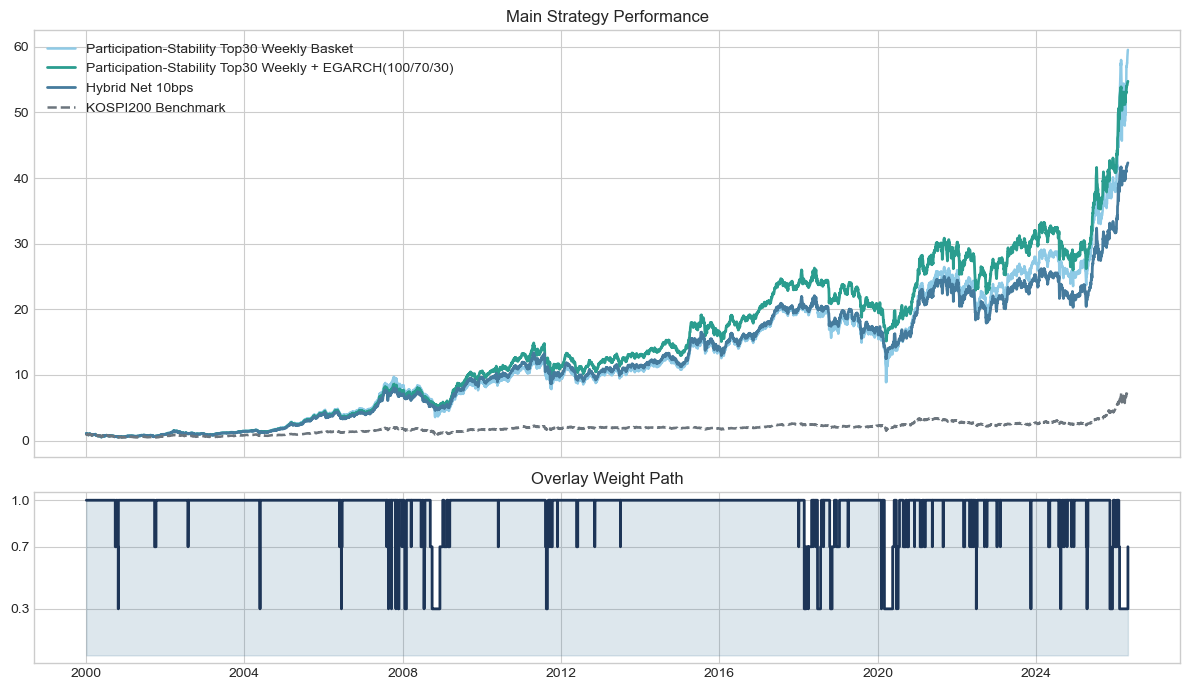

In [39]:
def build_basket_return(weight_df):
    basket = pd.Series(index=signal_dates, dtype=float)
    name_count = pd.Series(index=signal_dates, dtype=float)
    for dt in signal_dates:
        w = weight_df.loc[dt]
        names = w.index[w > 0].intersection(next_day_ret.columns)
        if len(names) == 0:
            basket.loc[dt] = 0.0
            name_count.loc[dt] = 0
            continue
        realized = next_day_ret.loc[dt, names].dropna()
        if len(realized) == 0:
            basket.loc[dt] = 0.0
            name_count.loc[dt] = 0
            continue
        ww = pd.Series(1.0 / len(realized), index=realized.index)
        basket.loc[dt] = float((realized * ww).sum())
        name_count.loc[dt] = len(realized)
    return basket, name_count


def build_effective_weights(weight_df, overlay_weight):
    return weight_df.mul(overlay_weight, axis=0).fillna(0.0)


def compute_turnover(weight_df):
    full_weight = weight_df.copy().fillna(0.0)
    full_weight["__CASH__"] = 1.0 - full_weight.sum(axis=1)
    turnover = full_weight.diff().abs().sum(axis=1) / 2.0
    turnover.iloc[0] = np.nan
    return turnover


def performance_stats(r):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)
    cum = (1 + r).cumprod()
    ann_ret = cum.iloc[-1] ** (252 / len(r)) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    mdd = (cum / cum.cummax() - 1).min()
    return pd.Series({"CAGR": ann_ret, "Ann.Vol": ann_vol, "Sharpe": sharpe, "MDD": mdd, "Days": len(r)})

BACKTEST_START = "2000-01-01"

next_day_ret = stock_ret.shift(-1)
next_market_ret = market_ret.shift(-1)
return_dates = pd.Series(stock_ret.index, index=stock_ret.index).shift(-1).reindex(signal_dates)
basket_ret, name_count = build_basket_return(weights)
effective_w = build_effective_weights(weights, regime["overlay_weight"])
turnover = compute_turnover(effective_w)
strategy_ret = basket_ret * regime["overlay_weight"]
# Compatibility aliases for downstream Gemini comparison cells.
port_ret = strategy_ret
equity = (1 + port_ret.fillna(0)).cumprod()
strategy_net = strategy_ret - turnover.fillna(0.0) * (ONE_WAY_COST_BPS / 10000.0)
benchmark_ret = next_market_ret.reindex(signal_dates)

backtest_signal = pd.concat([
    basket_ret.rename("Participation-Stability Top30 Weekly Basket"),
    strategy_ret.rename("Participation-Stability Top30 Weekly + EGARCH(100/70/30)"),
    strategy_net.rename(f"Hybrid Net {ONE_WAY_COST_BPS}bps"),
    benchmark_ret.rename("KOSPI200 Benchmark"),
    turnover.rename("Turnover"),
    regime["overlay_weight"].rename("Overlay Weight"),
    name_count.rename("Selected Names"),
    return_dates.rename("Return Date"),
], axis=1).dropna(subset=["Participation-Stability Top30 Weekly Basket", "Participation-Stability Top30 Weekly + EGARCH(100/70/30)", "KOSPI200 Benchmark", "Return Date"])
backtest_signal = backtest_signal.loc[backtest_signal["Return Date"] >= BACKTEST_START].copy()
print(
    "backtest signal window:",
    backtest_signal.index.min().date(),
    "->",
    backtest_signal.index.max().date(),
    "| return window:",
    backtest_signal["Return Date"].min().date(),
    "->",
    backtest_signal["Return Date"].max().date(),
    "| days:",
    len(backtest_signal),
)
backtest = backtest_signal.set_index("Return Date")
backtest.index.name = "Date"


perf = pd.concat([
    performance_stats(backtest["Participation-Stability Top30 Weekly Basket"]).rename("Participation-Stability Top30 Weekly Basket"),
    performance_stats(backtest["Participation-Stability Top30 Weekly + EGARCH(100/70/30)"]).rename("Participation-Stability Top30 Weekly + EGARCH(100/70/30)"),
    performance_stats(backtest[f"Hybrid Net {ONE_WAY_COST_BPS}bps"]).rename(f"Hybrid Net {ONE_WAY_COST_BPS}bps"),
    performance_stats(backtest["KOSPI200 Benchmark"]).rename("KOSPI200 Benchmark"),
], axis=1)
display(perf)

turnover_summary = pd.DataFrame({
    "Participation-Stability Top30 Weekly + EGARCH(100/70/30)": pd.Series({
        "Avg Daily Turnover": backtest["Turnover"].mean(),
        "Annualized Turnover": backtest["Turnover"].mean() * 252,
        "Total One-Way Turnover": backtest["Turnover"].sum(),
        f"Est.Ann.Cost@{ONE_WAY_COST_BPS}bps": backtest["Turnover"].mean() * 252 * (ONE_WAY_COST_BPS / 10000.0),
    })
})
display(turnover_summary)

cum = (1 + backtest[["Participation-Stability Top30 Weekly Basket", "Participation-Stability Top30 Weekly + EGARCH(100/70/30)", f"Hybrid Net {ONE_WAY_COST_BPS}bps", "KOSPI200 Benchmark"]]).cumprod()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1.2]})
axes[0].plot(cum.index, cum["Participation-Stability Top30 Weekly Basket"], label="Participation-Stability Top30 Weekly Basket", color="#8ecae6", linewidth=1.8)
axes[0].plot(cum.index, cum["Participation-Stability Top30 Weekly + EGARCH(100/70/30)"], label="Participation-Stability Top30 Weekly + EGARCH(100/70/30)", color="#2a9d8f", linewidth=2.0)
axes[0].plot(cum.index, cum[f"Hybrid Net {ONE_WAY_COST_BPS}bps"], label=f"Hybrid Net {ONE_WAY_COST_BPS}bps", color="#457b9d", linewidth=2.0)
axes[0].plot(cum.index, cum["KOSPI200 Benchmark"], label="KOSPI200 Benchmark", color="#6c757d", linestyle='--', linewidth=1.8)
axes[0].legend(frameon=False)
axes[0].set_title("Main Strategy Performance")
axes[1].step(backtest.index, backtest["Overlay Weight"], where='post', color="#1d3557", linewidth=2.0)
axes[1].fill_between(backtest.index, 0, backtest["Overlay Weight"], step='post', color="#457b9d", alpha=0.18)
axes[1].set_title("Overlay Weight Path")
axes[1].set_yticks([0.3,0.7,1.0])
plt.tight_layout()
plt.show()


### 4-1. 백테스트 결과 해석

`2000-01-04`부터 `2026-04-29`까지의 전체 구간에서 Participation-Stability Top30 바스켓은 연율 `17.20%`의 CAGR을 기록했고, KOSPI200 벤치마크의 `8.27%`를 크게 상회한다. 단순 누적성과 그래프에서도 바스켓과 전략 곡선이 장기적으로 벤치마크보다 뚜렷하게 높은 경로를 보인다.

EGARCH 오버레이를 적용한 전략은 CAGR이 `16.82%`로 원 바스켓의 `17.20%`보다 소폭 낮지만, 연율 변동성은 `26.50%`에서 `23.82%`로 낮아지고 MDD도 `-63.20%`에서 `-49.66%`로 개선된다. 즉 오버레이는 수익률을 극대화하기보다는 하락 구간의 손실 폭과 전체 변동성을 줄이는 위험관리 장치로 작동한다.

거래비용 10bps를 반영한 순성과는 CAGR `15.65%`, Sharpe `0.66`으로, 비용 차감 후에도 KOSPI200의 CAGR `8.27%`, Sharpe `0.34`보다 높다. 연환산 turnover는 약 `9.99배`로 높은 편이지만, 비용 반영 후에도 초과성과가 유지된다는 점에서 종목선택 신호의 장기 정보력은 남아 있다고 해석할 수 있다.

다만 그래프에서 2008년 금융위기, 2020년 코로나 충격, 2024년 이후 변동성 확대 구간처럼 큰 drawdown은 여전히 존재한다. 따라서 이 전략은 벤치마크 대비 장기 초과수익을 목표로 하되, 완전한 방어형 전략이라기보다는 고수익 바스켓에 변동성 레짐 기반의 노출 조절을 결합한 구조로 보는 것이 적절하다.


### 5. 2021년 이후 성과

최근장 적합성을 보기 위해 `2021년 이후` 성과를 따로 확인한다.
여기서도 `Basket`, `Basket + EGARCH`, `Net`, `Benchmark`를 함께 보아야,
최근 구간에서 EGARCH 오버레이가 실제로 도움이 되었는지 분리해서 해석할 수 있다.


,Participation-Stability Top30 Weekly Basket since 2021,Participation-Stability Top30 Weekly + EGARCH(100/70/30) since 2021,Hybrid Net 10bps since 2021,KOSPI200 Benchmark since 2021
CAGR,0.231498,0.173045,0.160433,0.201353
Ann.Vol,0.251602,0.215762,0.215773,0.235250
Sharpe,0.920096,0.802022,0.743524,0.855909
MDD,-0.269274,-0.273936,-0.284580,-0.361126
Days,1305.000000,1305.000000,1305.000000,1305.000000


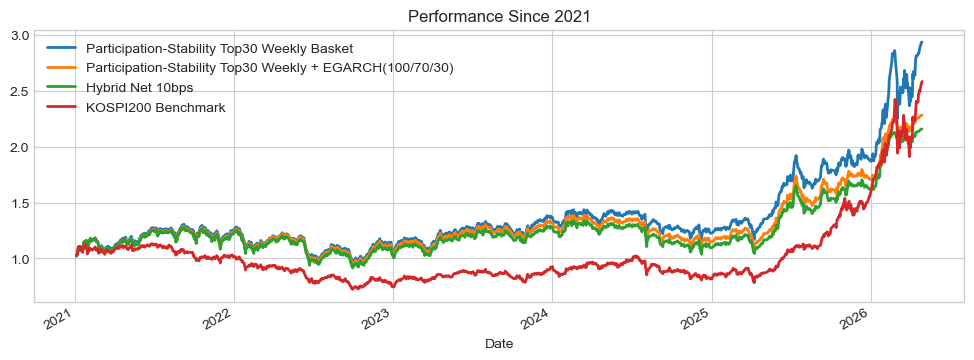

In [40]:
perf_2020 = pd.concat([
    performance_stats(backtest.loc[backtest.index >= "2021-01-01", "Participation-Stability Top30 Weekly Basket"]).rename("Participation-Stability Top30 Weekly Basket since 2021"),
    performance_stats(backtest.loc[backtest.index >= "2021-01-01", "Participation-Stability Top30 Weekly + EGARCH(100/70/30)"]).rename("Participation-Stability Top30 Weekly + EGARCH(100/70/30) since 2021"),
    performance_stats(backtest.loc[backtest.index >= "2021-01-01", f"Hybrid Net {ONE_WAY_COST_BPS}bps"]).rename(f"Hybrid Net {ONE_WAY_COST_BPS}bps since 2021"),
    performance_stats(backtest.loc[backtest.index >= "2021-01-01", "KOSPI200 Benchmark"]).rename("KOSPI200 Benchmark since 2021"),
], axis=1)
display(perf_2020)

cum_2020 = (1 + backtest.loc[backtest.index >= "2021-01-01", ["Participation-Stability Top30 Weekly Basket", "Participation-Stability Top30 Weekly + EGARCH(100/70/30)", f"Hybrid Net {ONE_WAY_COST_BPS}bps", "KOSPI200 Benchmark"]]).cumprod()
ax = cum_2020.plot(figsize=(12,4), linewidth=2.0, title="Performance Since 2021")
ax.legend(frameon=False)
plt.show()


### 5-1. 2021년 이후 성과 해석

`2021-01-01` 이후 구간에서는 Participation-Stability Top30 바스켓의 CAGR이 `23.15%`로 가장 높고, KOSPI200 벤치마크의 `20.14%`를 상회한다. 그래프에서도 2025년 이후 시장이 강하게 반등하는 구간에서 바스켓 곡선이 가장 크게 올라가며, 최근 상승장 참여도가 높았음을 보여준다.

다만 EGARCH 오버레이를 적용한 전략은 CAGR이 `17.30%`, 거래비용 차감 후 순성과는 `16.04%`로 낮아진다. 이는 최근 구간에서 오버레이가 일부 시점에 시장 노출을 줄이면서 상승장 참여도를 제한했기 때문이다. 즉 2021년 이후만 놓고 보면, EGARCH 오버레이는 수익률을 높이기보다는 변동성과 하락위험을 관리하는 역할에 가깝다.

위험 지표를 보면 바스켓의 Sharpe는 `0.92`로 가장 높고, EGARCH 적용 후 Sharpe는 `0.80`, 순성과 기준은 `0.74`다. 반면 MDD는 바스켓 `-26.93%`, EGARCH `-27.39%`, 순성과 `-28.46%`, KOSPI200 `-36.11%`로, 모든 전략 버전이 벤치마크보다 낙폭은 작다.

따라서 최근 구간의 핵심 해석은 명확하다. 종목선택 바스켓 자체는 최근장에서도 강한 정보력을 보였지만, EGARCH 오버레이는 강한 상승장에서는 성과를 일부 희생했다. 그 대신 벤치마크 대비 낮은 MDD를 유지했다는 점에서, 오버레이는 공격적인 알파 강화 장치라기보다 시장위험을 줄이는 보수적 노출 조절 장치로 해석하는 것이 적절하다.


### 6. 점수 정보력 점검: Quantile별 순성과 CAGR

메인 전략은 최상위 `Top30`만 사용하지만, 점수 자체가 정말 정보력이 있는지 보려면 전체 유니버스를 `quantile`로 나눠 보는 것이 좋다.

여기서는 매 리밸런싱 시점마다 `Participation-Stability Score`를 5분위(`Q1`~`Q5`)로 나누고,
각 분위 포트폴리오를 동일가중으로 보유했을 때의 `거래비용 10bp 반영 후 CAGR`을 비교한다.

- `Q5`: 점수 상위 20%
- `Q1`: 점수 하위 20%

즉 이 그래프는 `Top30 전략` 자체의 성과라기보다,
`점수 상위권이 실제로 하위권보다 더 좋은 성과를 내는지`를 단면적으로 확인하는 진단 도구라고 보면 된다.


/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_59467/4006972351.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reentry_trigger = investable_mask & (~investable_mask.shift(1).fillna(False))


,Q1,Q2,Q3,Q4,Q5
CAGR,-0.034333,0.007578,0.043271,0.080431,0.104091
Ann.Vol,0.302177,0.248741,0.219812,0.214633,0.224697
Sharpe,-0.113618,0.030465,0.196853,0.374735,0.463252
MDD,-0.948736,-0.829856,-0.696434,-0.618655,-0.584833
Days,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000
Avg Daily Turnover,0.033606,0.055132,0.059968,0.053545,0.029134
Annualized Turnover,8.468611,13.893264,15.112008,13.493328,7.341709


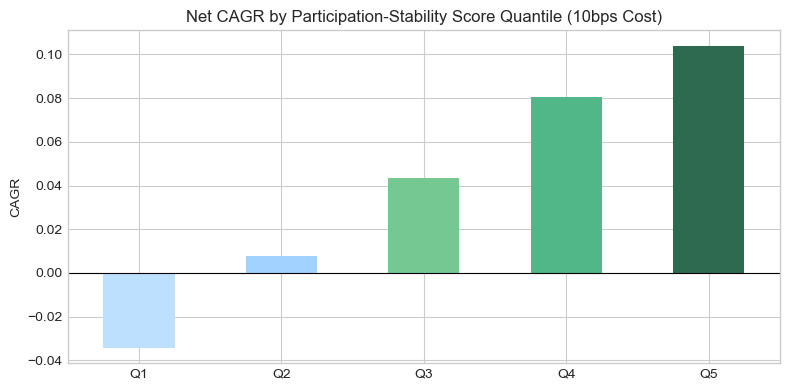

In [41]:
def build_quantile_selection(score_df, rebalance_dates_used, investable_mask, n_quantiles=5):
    quantile_weights = {}
    for q in range(1, n_quantiles + 1):
        quantile_weights[q] = pd.DataFrame(0.0, index=signal_dates, columns=price.columns)

    periodic_trigger = pd.Series(signal_dates.isin(rebalance_dates_used), index=signal_dates)
    reentry_trigger = investable_mask & (~investable_mask.shift(1).fillna(False))
    trigger = periodic_trigger | reentry_trigger

    current_names = {q: [] for q in range(1, n_quantiles + 1)}

    for dt in signal_dates:
        if not bool(investable_mask.loc[dt]):
            current_names = {q: [] for q in range(1, n_quantiles + 1)}
            continue

        if bool(trigger.loc[dt]) or all(len(v) == 0 for v in current_names.values()):
            score_today = score_df.loc[dt].reindex(price.columns).dropna().sort_values()
            if len(score_today) < n_quantiles:
                current_names = {q: [] for q in range(1, n_quantiles + 1)}
            else:
                try:
                    bucket = pd.qcut(score_today.rank(method="first"), q=n_quantiles, labels=False) + 1
                    current_names = {q: list(score_today.index[bucket == q]) for q in range(1, n_quantiles + 1)}
                except ValueError:
                    current_names = {q: [] for q in range(1, n_quantiles + 1)}

        for q in range(1, n_quantiles + 1):
            names = current_names[q]
            if len(names) == 0:
                continue
            quantile_weights[q].loc[dt, names] = 1.0 / len(names)

    return quantile_weights

quantile_weights = build_quantile_selection(hybrid_score, weekly_rebalance_dates, base_investable, n_quantiles=5)
quantile_perf = {}

for q, wgt in quantile_weights.items():
    q_basket_ret, _ = build_basket_return(wgt)
    q_effective_w = build_effective_weights(wgt, regime["overlay_weight"])
    q_turnover = compute_turnover(q_effective_w)
    q_gross = q_basket_ret * regime["overlay_weight"]
    q_net = q_gross - q_turnover.fillna(0.0) * (ONE_WAY_COST_BPS / 10000.0)
    stats = performance_stats(q_net)
    stats["Avg Daily Turnover"] = q_turnover.mean()
    stats["Annualized Turnover"] = q_turnover.mean() * 252
    quantile_perf[f"Q{q}"] = stats

quantile_perf = pd.DataFrame(quantile_perf)
display(quantile_perf)

q_order = [f"Q{i}" for i in range(1, 6)]
q_cagr = quantile_perf.loc["CAGR", q_order]
ax = q_cagr.plot(kind="bar", figsize=(8, 4), color=["#bde0fe", "#a2d2ff", "#76c893", "#52b788", "#2d6a4f"])
ax.set_title(f"Net CAGR by Participation-Stability Score Quantile ({ONE_WAY_COST_BPS}bps Cost)")
ax.set_ylabel("CAGR")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 7. 최근 선택 종목 점검

마지막 표는 최근 투자 시점 기준으로 실제 Top30 편입 종목을 보여준다.
Participation-Stability Score 상위권이 어떤 성격의 종목인지 빠르게 확인하는 용도다.


In [42]:
latest_invest_dt = selected.index[selected.sum(axis=1) > 0][-1]
latest_view = pd.DataFrame({
    "shr_beta_mkt": shr_beta_mkt.loc[latest_invest_dt],
    "shr_beta_hml": shr_beta_hml.loc[latest_invest_dt],
    "shr_beta_mom": shr_beta_mom.loc[latest_invest_dt],
    "beta_se": beta_se.loc[latest_invest_dt],
    "hybrid_score": hybrid_score.loc[latest_invest_dt],
    "selected": selected.loc[latest_invest_dt].astype(int),
}).dropna(subset=["hybrid_score"]).sort_values("hybrid_score", ascending=False)

print("latest invest date:", latest_invest_dt)
print("overlay weight:", regime.loc[latest_invest_dt, "overlay_weight"])
print("selected names:", int(selected.loc[latest_invest_dt].sum()))
display(latest_view.head(30))


latest invest date: 2026-04-29 00:00:00
overlay weight: 0.7
selected names: 30


,shr_beta_mkt,shr_beta_hml,shr_beta_mom,beta_se,hybrid_score,selected
삼성증권,1.077972,0.416563,0.060393,0.094231,0.889076,1
SK,1.122415,0.505733,0.185148,0.114351,0.876646,1
유안타증권,1.115815,0.376197,0.130360,0.107647,0.856723,1
DB증권,1.094667,0.434677,0.186445,0.118200,0.856057,1
현대차증권,1.136999,0.476353,0.082830,0.102896,0.855042,1
KCC,1.084619,0.324697,0.027717,0.121829,0.841562,1
교보증권,1.132484,0.464173,0.090993,0.111608,0.831513,1
대신증권,1.131609,0.483944,0.167122,0.124075,0.809489,1
NH투자증권,1.178283,0.439706,0.084459,0.106627,0.799580,1
한양증권,1.072354,0.192604,0.044617,0.112576,0.797094,1


### 7-1. 최신 선정 종목 해석

최신 투자일 기준 Top30은 `삼성증권`, `SK`, `유안타증권`, `DB증권`, `현대차증권` 등이 상위에 위치한다. 상위권에는 `삼성증권`, `유안타증권`, `DB증권`, `현대차증권`, `교보증권`, `대신증권`, `NH투자증권`, `한양증권`, `다올투자증권`, `한국금융지주`처럼 증권·금융 관련 종목이 많이 포함되어 있다. 이 종목들은 대체로 `shr_beta_mkt`가 `1.1` 근처에 있고, `shr_beta_hml`도 양호하게 나타나며, `beta_se`가 극단적으로 높지 않다. 즉 최근 점수식은 단순히 금융주라는 이유로 선택한 것이 아니라, 시장 상승에 참여할 수 있는 베타, 가치 팩터 노출, 비교적 안정적인 베타 추정치가 동시에 맞아떨어진 금융주들을 높게 평가한 것으로 볼 수 있다.

상위 종목들의 `shr_beta_mkt`는 대체로 `1.0~1.2` 부근에 모여 있다. 이는 점수식에서 시장 베타가 `1.1`에 가까운 종목을 선호하도록 설계했기 때문이다. 따라서 이 포트폴리오는 시장 방향성에 완전히 방어적으로 떨어져 있는 종목군이 아니라, 시장 상승에 적당히 참여할 수 있는 베타를 가진 종목군으로 구성된다.

`shr_beta_hml`은 삼성증권, SK, DB증권, GS건설, 롯데지주 등에서 비교적 높게 나타난다. 이는 가치 성향 또는 HML 팩터에 대한 노출이 있는 종목들이 점수에서 유리하게 작동했음을 의미한다. 반면 `shr_beta_mom`은 종목별로 차이가 크고, 대한항공이나 현대코퍼레이션처럼 음수인 종목도 포함되어 있어 모멘텀 하나만으로 선정된 포트폴리오는 아니다.

`beta_se`는 대체로 `0.09~0.15` 수준에 분포한다. 점수식이 beta 추정오차가 낮은 종목을 선호하기 때문에, 단순히 베타가 높은 종목이 아니라 추정 안정성이 어느 정도 확보된 종목이 선택된다. 다만 사조산업, 효성, 태광산업처럼 `beta_se`가 상대적으로 높은 종목도 포함되어 있어, 최종 순위는 베타 목표 근접도, HML, MOM, SMB, 추정오차가 합쳐진 결과로 보는 것이 맞다.

요약하면 최신 Top30은 `시장 베타 1.1 근처`, `가치 팩터 노출`, `베타 추정 안정성`을 동시에 만족하는 종목을 중심으로 구성되어 있다. 현재 포트폴리오는 금융주 비중이 높다는 점이 특징이므로, 향후 해석에서는 성과가 개별 종목선택 효과인지, 금융 섹터 쏠림 효과인지도 함께 점검할 필요가 있다.


### 8. 결과 저장

이 노트북은 메인 전략 관련 핵심 결과만 저장한다.

- `main_top30_backtest.csv`
- `main_top30_perf.csv`
- `main_top30_perf_2020.csv`
- `main_top30_turnover_summary.csv`
- `main_top30_selected_portfolio.csv`
- `main_top30_quantile_perf.csv`


In [43]:
backtest.to_csv("main_top30_backtest.csv", encoding="utf-8-sig")
perf.to_csv("main_top30_perf.csv", encoding="utf-8-sig")
perf_2020.to_csv("main_top30_perf_2020.csv", encoding="utf-8-sig")
turnover_summary.to_csv("main_top30_turnover_summary.csv", encoding="utf-8-sig")
selected.astype(int).to_csv("main_top30_selected_portfolio.csv", encoding="utf-8-sig")
quantile_perf.to_csv("main_top30_quantile_perf.csv", encoding="utf-8-sig")

print("saved:")
print("- main_top30_backtest.csv")
print("- main_top30_perf.csv")
print("- main_top30_perf_2020.csv")
print("- main_top30_turnover_summary.csv")
print("- main_top30_selected_portfolio.csv")
print("- main_top30_quantile_perf.csv")


saved:
- main_top30_backtest.csv
- main_top30_perf.csv
- main_top30_perf_2020.csv
- main_top30_turnover_summary.csv
- main_top30_selected_portfolio.csv
- main_top30_quantile_perf.csv


### 9. 해석 가이드

이 노트북은 메인 전략을 빠르게 검증하기 위한 버전이다.
성과 해석은 아래 순서로 하면 자연스럽다.

1. 전체 구간에서 벤치마크 대비 수익률, 변동성, 낙폭을 확인한다.
2. turnover와 10bp 순성과를 함께 보며 실제 운용 가능성을 점검한다.
3. `2021년 이후` 성과를 따로 보며 최근장 적합성을 확인한다.
4. `Quantile CAGR` 그래프로 Participation-Stability Score 상위권이 실제로 더 나은지 확인한다.
5. 마지막으로 최근 선택 종목을 보며 현재 점수식이 어떤 종목군을 선호하는지 점검한다.


In [44]:
# ============================================================
# Gemini AI-Tilt cache 설정
# ============================================================

AI_TILT_STRENGTH = 0.70
AI_MIN_WEIGHT = 0.50
AI_MAX_WEIGHT = 1.80

GEMINI_CACHE_PATH = Path("gemini_ai_score_cache_5y.csv")

In [45]:
# ============================================================
# 캐시 기반 AI-Tilt 점수 및 비중 생성
# ============================================================

def load_gemini_score_cache(cache_path=GEMINI_CACHE_PATH):
    if not cache_path.exists():
        raise FileNotFoundError(f"AI-Tilt score cache 파일이 없습니다: {cache_path}")

    cache = pd.read_csv(cache_path)
    required_cols = {"date", "ticker", "ai_score"}
    missing_cols = required_cols - set(cache.columns)
    if missing_cols:
        raise ValueError("AI-Tilt score cache 필수 컬럼 누락: " + ", ".join(sorted(missing_cols)))

    cache = cache.copy()
    cache["date"] = pd.to_datetime(cache["date"]).dt.strftime("%Y-%m-%d")
    cache["ticker"] = cache["ticker"].astype(str)
    cache["ai_score"] = pd.to_numeric(cache["ai_score"], errors="coerce")
    if "reason" not in cache.columns:
        cache["reason"] = ""
    cache["reason"] = cache["reason"].fillna("").astype(str)
    cache = cache.dropna(subset=["date", "ticker", "ai_score"])
    cache = cache.drop_duplicates(subset=["date", "ticker"], keep="last")

    print(f"[Cache Loaded] {len(cache):,} rows from {cache_path}")
    return cache


gemini_cache_df = load_gemini_score_cache()


def get_cached_scores(dt, selected_names):
    date_key = pd.Timestamp(dt).strftime("%Y-%m-%d")
    selected_names = [str(name) for name in selected_names]

    cached = gemini_cache_df[
        (gemini_cache_df["date"] == date_key) &
        (gemini_cache_df["ticker"].isin(selected_names))
    ].copy()

    if cached.empty:
        return pd.DataFrame(columns=["ai_score", "reason"])

    return cached.set_index("ticker")[["ai_score", "reason"]]


def build_ai_tilt_weights(
    selected_df,
    rebalance_dates_used,
    investable_mask,
    top_n=30,
):
    ai_score_df = pd.DataFrame(np.nan, index=signal_dates, columns=price.columns)
    ai_weights = pd.DataFrame(0.0, index=signal_dates, columns=price.columns)
    ai_reason_dict = {}

    periodic_trigger = pd.Series(
        signal_dates.isin(rebalance_dates_used),
        index=signal_dates,
    )
    reentry_trigger = investable_mask & (~investable_mask.shift(1).fillna(False))
    trigger = periodic_trigger | reentry_trigger

    cache_start = min(rebalance_dates_used)
    cache_end = max(rebalance_dates_used)
    current_weights = pd.Series(0.0, index=price.columns)
    missing_cache_dates = []
    processed_dates = 0

    for dt in signal_dates:
        if (dt < cache_start) or (dt > cache_end):
            current_weights[:] = 0.0
            ai_weights.loc[dt] = current_weights
            continue

        if not bool(investable_mask.loc[dt]):
            current_weights[:] = 0.0
            ai_weights.loc[dt] = current_weights
            continue

        if bool(trigger.loc[dt]) or current_weights.sum() == 0:
            selected_names = selected_df.columns[selected_df.loc[dt]].astype(str).tolist()
            if len(selected_names) == 0:
                current_weights[:] = 0.0
                ai_weights.loc[dt] = current_weights
                continue

            cached_scores = get_cached_scores(dt, selected_names)
            valid_names = [name for name in selected_names if name in cached_scores.index]

            current_weights[:] = 0.0

            if len(valid_names) == 0:
                current_weights.loc[selected_names] = 1.0 / len(selected_names)
                missing_cache_dates.append(pd.Timestamp(dt).strftime("%Y-%m-%d"))
            else:
                raw_score = cached_scores.loc[valid_names, "ai_score"].astype(float)
                rank_score = raw_score.rank(pct=True)

                ai_score_df.loc[dt, valid_names] = raw_score.reindex(valid_names)
                ai_reason_dict[str(pd.Timestamp(dt).date())] = (
                    cached_scores.loc[valid_names, "reason"].fillna("").to_dict()
                )

                base_w = 1.0 / len(valid_names)
                tilt = 1.0 + AI_TILT_STRENGTH * (rank_score - rank_score.mean())
                tilt = tilt.clip(lower=AI_MIN_WEIGHT, upper=AI_MAX_WEIGHT)

                w = base_w * tilt
                current_weights.loc[valid_names] = w / w.sum()

            processed_dates += 1

        ai_weights.loc[dt] = current_weights

    print(f"[Cache Weights Built] {processed_dates:,} rebalance/re-entry dates processed")
    if missing_cache_dates:
        preview = ", ".join(missing_cache_dates[:5])
        suffix = " ..." if len(missing_cache_dates) > 5 else ""
        print(f"[Cache Missing] {len(missing_cache_dates):,} dates used equal-weight fallback: {preview}{suffix}")

    return ai_score_df, ai_weights, ai_reason_dict

[Cache Loaded] 7,860 rows from gemini_ai_score_cache_5y.csv


In [46]:
# ============================================================
# 최근 5년치 리밸런싱 날짜: 캐시에 있는 날짜만 사용
# ============================================================

end_dt = signal_dates.max()
start_dt = end_dt - pd.DateOffset(years=5)

weekly_rebalance_dates_5y = [
    dt for dt in weekly_rebalance_dates
    if (dt >= start_dt) and (dt <= end_dt)
]

cache_dates_5y = pd.DatetimeIndex(
    pd.to_datetime(gemini_cache_df["date"].unique())
).sort_values()
cache_date_set = set(cache_dates_5y)

gemini_rebalance_dates_5y = [
    dt for dt in weekly_rebalance_dates_5y
    if dt in cache_date_set
]

print("5Y start:", start_dt)
print("5Y end:", end_dt)
print("5Y weekly rebalance count:", len(weekly_rebalance_dates_5y))
print("Gemini cached rebalance count:", len(gemini_rebalance_dates_5y))
print("Gemini cache date range:", cache_dates_5y.min(), "->", cache_dates_5y.max())

5Y start: 2021-04-29 00:00:00
5Y end: 2026-04-29 00:00:00
5Y weekly rebalance count: 262
Gemini cached rebalance count: 262
Gemini cache date range: 2021-04-30 00:00:00 -> 2026-04-29 00:00:00


In [47]:
# ============================================================
# AI-Tilt weights 생성: 캐시 재점수 기반 최근 5년치
# ============================================================

cache_ai_score, ai_tilt_weights, ai_tilt_reasons = build_ai_tilt_weights(
    selected_df=selected,
    rebalance_dates_used=gemini_rebalance_dates_5y,
    investable_mask=base_investable,
    top_n=TOP_N,
)

/var/folders/88/rtxw1tvn1_76nvq3k5qffnjm0000gn/T/ipykernel_59467/3041183166.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reentry_trigger = investable_mask & (~investable_mask.shift(1).fillna(False))


[Cache Weights Built] 262 rebalance/re-entry dates processed


In [48]:
# ============================================================
# Custom weight용 수익률 계산 함수
# 기존 build_basket_return()은 수정하지 않음
# ============================================================

def build_basket_return_with_custom_weights(weight_df):
    basket = pd.Series(index=signal_dates, dtype=float)
    name_count = pd.Series(index=signal_dates, dtype=float)

    for dt in signal_dates:
        w = weight_df.loc[dt].dropna()
        names = w.index[w > 0].intersection(next_day_ret.columns)

        if len(names) == 0:
            basket.loc[dt] = 0.0
            name_count.loc[dt] = 0
            continue

        realized = next_day_ret.loc[dt, names].dropna()

        if len(realized) == 0:
            basket.loc[dt] = 0.0
            name_count.loc[dt] = 0
            continue

        ww = w.reindex(realized.index).fillna(0.0)

        if ww.sum() <= 0:
            basket.loc[dt] = 0.0
            name_count.loc[dt] = 0
            continue

        ww = ww / ww.sum()

        basket.loc[dt] = float((realized * ww).sum())
        name_count.loc[dt] = len(realized)

    return basket, name_count

In [49]:
# ============================================================
# 성과지표 함수
# ============================================================

def simple_perf_stats(ret, ann_factor=252):
    ret = ret.dropna()

    if len(ret) == 0:
        return pd.Series({
            "Total Return": np.nan,
            "Annual Return": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe": np.nan,
            "MDD": np.nan,
        })

    total_return = (1 + ret).prod() - 1
    ann_return = (1 + total_return) ** (ann_factor / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(ann_factor)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    equity_curve = (1 + ret).cumprod()
    drawdown = equity_curve / equity_curve.cummax() - 1
    mdd = drawdown.min()

    return pd.Series({
        "Total Return": total_return,
        "Annual Return": ann_return,
        "Annual Volatility": ann_vol,
        "Sharpe": sharpe,
        "MDD": mdd,
    })


,Equal Weight 5Y,AI-Tilt Re-Score 5Y
Total Return,1.000725,1.050554
Annual Return,0.153343,0.159195
Annual Volatility,0.215656,0.216244
Sharpe,0.711055,0.736180
MDD,-0.273936,-0.281953


Text(0, 0.5, 'Cumulative Return Index')

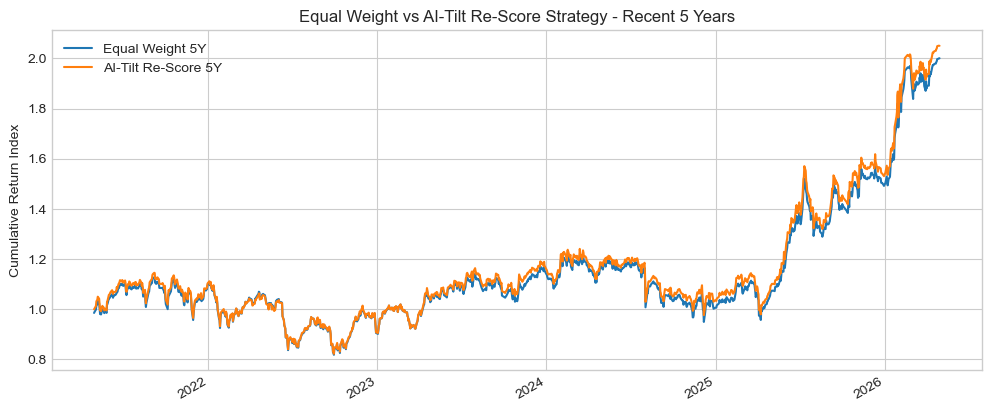

In [50]:
# ============================================================
# 최근 5년치 성과 계산
# ============================================================

ai_tilt_basket_ret, ai_tilt_name_count = build_basket_return_with_custom_weights(
    ai_tilt_weights
)

ai_tilt_port_ret = ai_tilt_basket_ret * regime["overlay_weight"]
ai_tilt_equity = (1 + ai_tilt_port_ret.fillna(0)).cumprod()

port_ret_5y = port_ret.loc[start_dt:end_dt]
ai_tilt_port_ret_5y = ai_tilt_port_ret.loc[start_dt:end_dt]

equity_5y = (1 + port_ret_5y.fillna(0)).cumprod()
ai_tilt_equity_5y = (1 + ai_tilt_port_ret_5y.fillna(0)).cumprod()

perf_compare_5y = pd.DataFrame({
    "Equal Weight 5Y": simple_perf_stats(port_ret_5y),
    "AI-Tilt Re-Score 5Y": simple_perf_stats(ai_tilt_port_ret_5y),
})

display(perf_compare_5y)

equity_compare_5y = pd.DataFrame({
    "Equal Weight 5Y": equity_5y,
    "AI-Tilt Re-Score 5Y": ai_tilt_equity_5y,
}).dropna()

ax = equity_compare_5y.plot(
    figsize=(12, 5),
    title="Equal Weight vs AI-Tilt Re-Score Strategy - Recent 5 Years"
)

ax.set_ylabel("Cumulative Return Index")

In [51]:
# ============================================================
# 최신 AI-Tilt 재점수 및 비중 확인
# ============================================================

latest_ai_dt = ai_tilt_weights.index[
    ai_tilt_weights.sum(axis=1) > 0
][-1]

latest_selected_names = selected.columns[selected.loc[latest_ai_dt]].tolist()
latest_valid_names = [
    name for name in latest_selected_names
    if ai_tilt_weights.loc[latest_ai_dt, name] > 0
]

latest_ai_tilt_view = pd.DataFrame({
    "equal_weight": weights.loc[latest_ai_dt, latest_valid_names],
    "cache_ai_score": cache_ai_score.loc[latest_ai_dt, latest_valid_names],
    "ai_tilt_weight": ai_tilt_weights.loc[latest_ai_dt, latest_valid_names],
    "hybrid_score": hybrid_score.loc[latest_ai_dt, latest_valid_names],
}).sort_values("ai_tilt_weight", ascending=False)

print("latest AI-Tilt date:", latest_ai_dt)
display(latest_ai_tilt_view)

latest AI-Tilt date: 2026-04-29 00:00:00


,equal_weight,cache_ai_score,ai_tilt_weight,hybrid_score
현대코퍼레이션,0.033333,95.0,0.044611,0.743732
SK,0.033333,92.5,0.043833,0.876646
GS건설,0.033333,90.0,0.043056,0.771499
LS증권,0.033333,87.5,0.042278,0.768873
삼지전자,0.033333,85.0,0.041500,0.747024
한양증권,0.033333,82.5,0.040722,0.797094
효성,0.033333,80.0,0.039944,0.792437
삼성생명,0.033333,77.5,0.039167,0.789531
유안타증권,0.033333,75.0,0.038389,0.856723
NH투자증권,0.033333,72.5,0.037611,0.799580
